In [ ]:
# Upload the kaggle.json file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aravraval","key":"ebef5ded3076c5c1ad3355fa4c39a3c8"}'}

In [ ]:
import os
# Move the uploaded kaggle.json file to the appropriate directory
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')

# Install Kaggle API client if not already installed
!pip install -q kaggle

datasets = ['amitanshjoshi/spotify-1million-tracks']

# Download dataset via Kaggle API
for dataset in datasets:
  !kaggle datasets download -d {dataset} -p /content/zip_files/

# Unzip the downloaded datasets
for dataset in datasets:
    # Extract the dataset name from the path
    dataset_name = dataset.split('/')[-1]  # This gets the file name, e.g., 'spotify-tracks-dataset.zip'

    # Create the target extraction directory if it doesn't exist
    target_dir = f'/content/dataset/{dataset.split("/")[0]}/'
    os.makedirs(target_dir, exist_ok=True)

    # Unzip the dataset into the specified directory
    !unzip /content/zip_files/{dataset_name} -d {target_dir}

Dataset URL: https://www.kaggle.com/datasets/amitanshjoshi/spotify-1million-tracks
License(s): ODbL-1.0
spotify-1million-tracks.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  /content/zip_files/spotify-1million-tracks.zip
replace /content/dataset/amitanshjoshi/spotify_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
#View the columns/first few rows of the dataset
import pandas as pd
input_dataset = '/content/dataset/amitanshjoshi/spotify_data.csv'
df = pd.read_csv(input_dataset)
df.head()

,Unnamed: 0,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0,Jason Mraz,I Won't Give Up,53QF56cjZA9RTuuMZDrSA6,68,2012,acoustic,0.483,0.303,4,-10.058,1,0.0429,0.6940,0.000000,0.1150,0.139,133.406,240166,3
1,1,Jason Mraz,93 Million Miles,1s8tP3jP4GZcyHDsjvw218,50,2012,acoustic,0.572,0.454,3,-10.286,1,0.0258,0.4770,0.000014,0.0974,0.515,140.182,216387,4
2,2,Joshua Hyslop,Do Not Let Me Go,7BRCa8MPiyuvr2VU3O9W0F,57,2012,acoustic,0.409,0.234,3,-13.711,1,0.0323,0.3380,0.000050,0.0895,0.145,139.832,158960,4
3,3,Boyce Avenue,Fast Car,63wsZUhUZLlh1OsyrZq7sz,58,2012,acoustic,0.392,0.251,10,-9.845,1,0.0363,0.8070,0.000000,0.0797,0.508,204.961,304293,4
4,4,Andrew Belle,Sky's Still Blue,6nXIYClvJAfi6ujLiKqEq8,54,2012,acoustic,0.430,0.791,6,-5.419,0,0.0302,0.0726,0.019300,0.1100,0.217,171.864,244320,4


In [ ]:
# Helper function for extracting featured artists
import re

def extract_featured_artists(track_name):
    """
    Extract featured artists from a track title, cleaning remix or version suffixes.
    """
    # Look for 'feat.', 'featuring', 'ft.' (case insensitive)
    pattern = re.compile(r'(feat\.|featuring|ft\.)\s*(.+?)(?:\)|-|$)', re.IGNORECASE)
    match = pattern.search(track_name)

    if not match:
        return []

    featured_part = match.group(2)

    # Clean brackets if any slipped through
    featured_part = re.sub(r'[\(\)\[\]]', '', featured_part)

    # Now split based on common separators between multiple featured artists
    featured_artists = re.split(r',|&|and|/', featured_part)

    # Strip spaces and cleanup
    featured_artists = [artist.strip() for artist in featured_artists if artist.strip()]

    return featured_artists


In [ ]:
# Convert clean dataset to network json
import networkx as nx
import json
import pickle
import ast

network_data = {
    'nodes': set(),
    'edges': []
}

columns_to_keep = ['artist_name', 'track_name', 'track_id', 'popularity', 'year',
                   'genre', 'danceability',	'energy',	'loudness',	'speechiness',
                   'acousticness',	'instrumentalness',	'liveness',	'valence']


# File path
output_file = 'network_data.pkl'

# Chunk size for processing in chunks
chunk_size = 100000  # Adjust this depending on available memory

# Function to save network data intermittently
def save_network_data():
    with open(output_file, 'wb') as f:
        pickle.dump(network_data, f)
    print("Network data saved successfully.")

# Read the cleaned dataset in chunks and process each chunk
chunks = pd.read_csv(input_dataset, chunksize=chunk_size, usecols=columns_to_keep, on_bad_lines='skip')

for chunk_index, chunk in enumerate(chunks):
    print(f"Processing chunk {chunk_index + 1}...")

    # Iterate through the rows of the current chunk
    for _, row in chunk.iterrows():
        # Skip over the blank / NaN lines
        if not isinstance(row['artist_name'], str):
            continue
        elif not isinstance(row['track_name'], str):
            continue
        elif not isinstance(row['track_id'], str):
            continue

        # Return features of a song
        featured_artists = extract_featured_artists(row['track_name'])


        # Extract features for the edge (like valence, popularity)
        edge_attributes = {
            'track_name': row['track_name'],
            'track_id': row['track_id'],
            'popularity': row['popularity'],
            'year': row['year'],
            'track_genre': row['genre'],
            'energy': row['energy'],
            'danceability': row['danceability'],
            'acousticness': row['acousticness'],
            'liveness': row['liveness'],
            'instrumentalness': row['instrumentalness'],
            'valence': row['valence'],
            'loudness': row['loudness'],
            'speechiness': row['speechiness']
        }

        network_data['nodes'].add(row['artist_name'])

        # Add featured artists to nodes
        for artist in featured_artists:
            network_data['nodes'].add(artist)
            edge = tuple(sorted([row['artist_name'], artist]))
            network_data['edges'].append((edge, edge_attributes))

    # Save intermittently after each chunk is processed
    save_network_data()

print("Network data creation complete.")


Processing chunk 1...
Network data saved successfully.
Processing chunk 2...
Network data saved successfully.
Processing chunk 3...
Network data saved successfully.
Processing chunk 4...
Network data saved successfully.
Processing chunk 5...
Network data saved successfully.
Processing chunk 6...
Network data saved successfully.
Processing chunk 7...
Network data saved successfully.
Processing chunk 8...
Network data saved successfully.
Processing chunk 9...
Network data saved successfully.
Processing chunk 10...
Network data saved successfully.
Processing chunk 11...
Network data saved successfully.
Processing chunk 12...
Network data saved successfully.
Network data creation complete.


# **Visualization**

In [ ]:
# Print a few nodes (first 5 nodes)
print("Sample of nodes:")
print(list(network_data['nodes'])[:35])  # Convert to list and print first 5 nodes

# Print a few edges (first 5 edges)
print("\nSample of edges:")
for edge in network_data['edges']:  # Print first 5 edges
    #print(edge)
    if edge[0][0] == 'Talib Kweli':
        print(edge)

print(len(network_data['nodes']))
print(len(network_data['edges']))

Sample of nodes:
['Sudam Majhi', 'Dub Wiser', 'Kasper Koman', 'Alley Boy', 'Errol Dunkley', 'Run Level Zero', 'Tim Atlas', 'Francis M.', 'Anish Sood', 'Rodolfo Roballos', 'Afrirampo', 'Taliesin Orchestra', 'Los Kung Fu Monkeys', 'Storm The Sky', 'Sheryl Bailey', 'James Curd', 'Claire Guyot', 'Rekha Bhardwaj', 'Rumbo Tumba', 'HONEYMOAN', 'TICO DE MORAES', 'marvy ayy', 'Yaron Herman Trio', 'Bangkok Impact', 'Joey Ramone', 'Braken', 'Hanna Talikainen', 'Stefano Noferini', 'Perpetuous Dreamer', 'LANNÉ', 'E. Gayathri', 'David Quinlan', 'Pere Ubu', 'Cape Coral', 'David Francey']

Sample of edges:
(('Talib Kweli', 'Talib Kweli'), {'track_name': 'Bounce feat. Talib Kweli', 'track_id': '0HKfITkjIOvSmefIS2VIGp', 'popularity': 26, 'year': 2017, 'track_genre': 'hardcore', 'energy': 0.608, 'danceability': 0.775, 'acousticness': 0.571, 'liveness': 0.379, 'instrumentalness': 2.32e-05, 'valence': 0.286, 'loudness': -6.9, 'speechiness': 0.142})
(('Talib Kweli', 'will.i.am'), {'track_name': 'Hot Thing (

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33673 (\N{CJK UNIFIED IDEOGRAPH-8389}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21608 (\N{CJK UNIFIED IDEOGRAPH-5468}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22905 (\N{CJK UNIFIED IDEOGRAPH-5979}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35498 (\N{CJK UNIFIED IDEOGRAPH-8AAA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38515 (\N{CJK UNIFIED IDEOGRAPH-9673}) missing from font(s) DejaVu Sans.
  fig.canvas

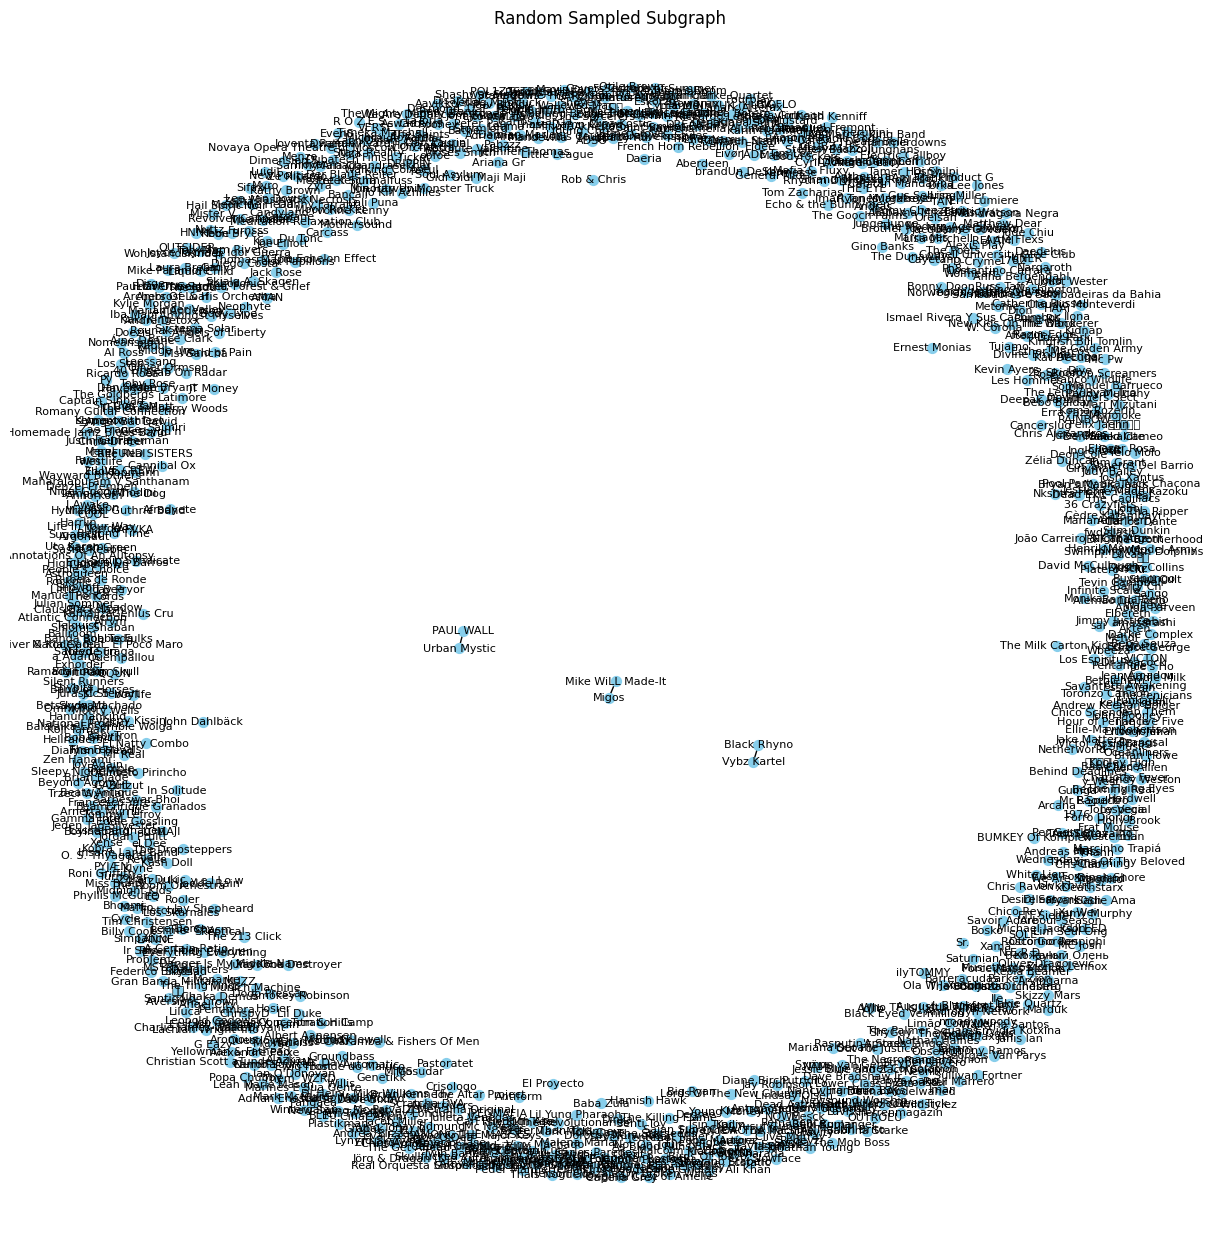

In [ ]:
import networkx as nx
import random
import matplotlib.pyplot as plt

# Load your graph from the pickle file
with open('network_data.pkl', 'rb') as f:
    network_data = pickle.load(f)

# Create a NetworkX graph from the data
G = nx.Graph()

# Add nodes and edges from the network_data dictionary
G.add_nodes_from(network_data['nodes'])
for edge, attributes in network_data['edges']:
    G.add_edge(edge[0], edge[1], **attributes)

# Select a random subset of nodes and edges (e.g., 1000 nodes)
sampled_nodes = random.sample(list(G.nodes), 1000)  # Adjust size of subset as needed
subgraph = G.subgraph(sampled_nodes)

# Visualize the subgraph
plt.figure(figsize=(12, 12))

# Use spring layout for node positioning
pos = nx.spring_layout(subgraph, seed=42, k=0.1)  # Adjust 'k' for spacing

# Draw the subgraph
nx.draw(subgraph, pos, with_labels=True, node_size=50, font_size=8, node_color='skyblue', font_color='black')

plt.title("Random Sampled Subgraph")
plt.show()

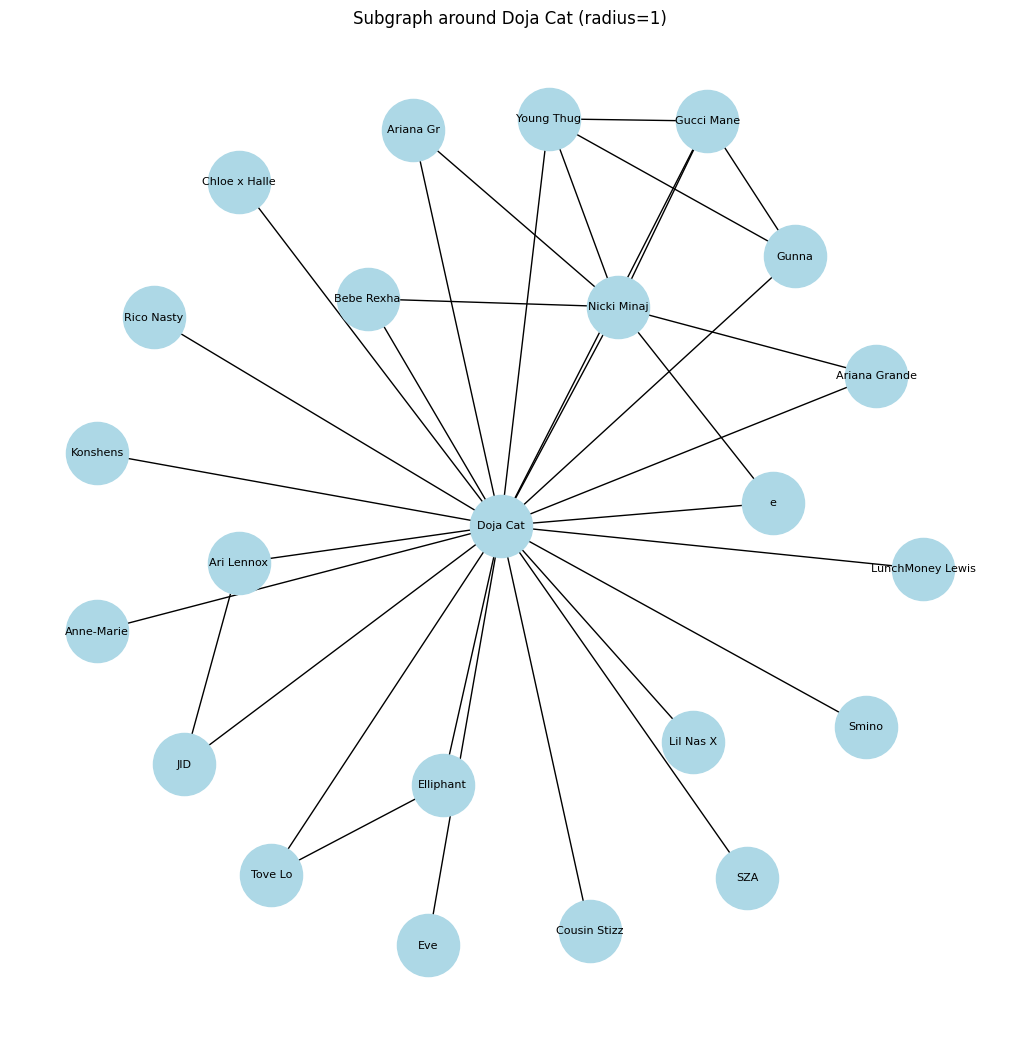

In [ ]:
# Show a subgraph centered around the given artist
plt.figure(figsize=(10, 10))
artist = 'Doja Cat'
radius = 1
subgraph = nx.ego_graph(G, artist, radius=radius)

# Draw the subgraph
pos = nx.kamada_kawai_layout(subgraph)
nx.draw(subgraph, pos, with_labels=True, node_color="lightblue", node_size=2000, font_size=8)
plt.title(f"Subgraph around {artist} (radius={radius})")
plt.show()

In [ ]:
# Creating an interactive / scrollable graph: Still work in progress
pos = nx.spring_layout(G, seed=42, k=0.1)
import plotly.graph_objects as go

# Create a Plotly graph
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.append(x0)
    edge_x.append(x1)
    edge_y.append(y0)
    edge_y.append(y1)

# Create a scatter plot for nodes
node_x = []
node_y = []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

# Plot edges
edge_trace = go.Scatter(x=edge_x, y=edge_y,
                        line=dict(width=0.5, color='#888'),
                        hoverinfo='none',
                        mode='lines')

# Plot nodes
node_trace = go.Scatter(x=node_x, y=node_y,
                        mode='markers',
                        hoverinfo='text',
                        marker=dict(color='skyblue', size=10))

# Create layout
layout = go.Layout(title="Graph Visualization with Plotly",
                   showlegend=False,
                   hovermode='closest',
                   xaxis=dict(showgrid=False, zeroline=False),
                   yaxis=dict(showgrid=False, zeroline=False))

# Plot
fig = go.Figure(data=[edge_trace, node_trace], layout=layout)
fig.show()

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import networkx as nx
import re
from collections import defaultdict

# Function to extract featured artists
def extract_featured_artists(track_name):
    pattern = re.compile(r'(feat\.|featuring|ft\.)\s*(.+?)(?:\)|-|$)', re.IGNORECASE)
    match = pattern.search(track_name)
    if not match:
        return []
    featured_part = match.group(2)
    featured_part = re.sub(r'[\(\)\[\]]', '', featured_part)
    featured_artists = re.split(r',|&|and|/', featured_part)
    featured_artists = [artist.strip() for artist in featured_artists if artist.strip()]
    return featured_artists

# Initialize graph
G = nx.Graph()

# Dictionaries to track sum of popularity and count of songs
artist_popularity_sum = defaultdict(int)
artist_song_count = defaultdict(int)

# Load the dataset
df = pd.read_csv('your_spotify_tracks.csv')  # <-- your file

# Process each song
for idx, row in df.iterrows():
    main_artist = row['main_artist']  # Replace with your actual column
    track_name = row['track_name']
    song_popularity = row['popularity']

    featured_artists = extract_featured_artists(track_name)

    all_artists = [main_artist] + featured_artists

    for artist in all_artists:
        artist_popularity_sum[artist] += song_popularity
        artist_song_count[artist] += 1

    # Add collaboration edges
    for feat_artist in featured_artists:
        G.add_edge(main_artist, feat_artist)

# Assign node weights based on average popularity
for artist in artist_popularity_sum:
    avg_popularity = artist_popularity_sum[artist] / artist_song_count[artist]
    G.add_node(artist, weight=avg_popularity)


## **Analysis**

In [ ]:
import networkx as nx
import pickle

# Load the network data from the pickle file
with open('network_data.pkl', 'rb') as f:
    network_data = pickle.load(f)

# Create a NetworkX graph from the data
G = nx.Graph()

# Add nodes and edges from the network_data dictionary
G.add_nodes_from(network_data['nodes'])
for edge, attributes in network_data['edges']:
    G.add_edge(edge[0], edge[1], **attributes)

# Degree Centrality
degree_centrality = nx.degree_centrality(G)
# Sort and get top 10 nodes
top_10_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 Degree Centrality:")
for node, centrality in top_10_degree:
    print(f"{node}: {centrality}")

# Betweenness Centrality
betweenness_centrality = nx.betweenness_centrality(G)
# Sort and get top 10 nodes
top_10_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 Betweenness Centrality:")
for node, centrality in top_10_betweenness:
    print(f"{node}: {centrality}")

# Closeness Centrality
closeness_centrality = nx.closeness_centrality(G)
# Sort and get top 10 nodes
top_10_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 Closeness Centrality:")
for node, centrality in top_10_closeness:
    print(f"{node}: {centrality}")

# Eigenvector Centrality
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-06)
# Sort and get top 10 nodes
top_10_eigenvector = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 Eigenvector Centrality:")
for node, centrality in top_10_eigenvector:
    print(f"{node}: {centrality}")

Top 10 Degree Centrality:
Chris Brown: 0.0015833100493620193
Ty Dolla $ign: 0.001543394669966338
Snoop Dogg: 0.0013970382788488405
Gucci Mane: 0.0012107665083356618
Nas: 0.0011841562554052076
David Guetta: 0.0011043254966138453
Wiz Khalifa: 0.0010777152436833913
Epik High: 0.0010244947378224832
Future: 0.001011189611357256
Freddie Gibbs: 0.001011189611357256


KeyboardInterrupt: 